In [31]:
from stardist.models import Config3D, StarDist3D
from csbdeep.utils import  normalize
from stardist import fill_label_holes, random_label_cmap, calculate_extents, gputools_available
from stardist import Rays_GoldenSpiral
from skimage.measure import regionprops
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import xarray as xr
from projections import *
import patchify
import pandas as pd
from stardist.plot import render_label
import h5py


## Helper/Plotting functions

In [2]:
lbl_cmap = random_label_cmap()

In [6]:
axis_norm = (0,1,2)

In [13]:
def random_fliprot(img, mask, axis=None): 
    if axis is None:
        axis = tuple(range(mask.ndim))
    axis = tuple(axis)
            
    assert img.ndim>=mask.ndim
    perm = tuple(np.random.permutation(axis))
    transpose_axis = np.arange(mask.ndim)
    for a, p in zip(axis, perm):
        transpose_axis[a] = p
    transpose_axis = tuple(transpose_axis)
    img = img.transpose(transpose_axis + tuple(range(mask.ndim, img.ndim))) 
    mask = mask.transpose(transpose_axis) 
    for ax in axis: 
        if np.random.rand() > 0.5:
            img = np.flip(img, axis=ax)
            mask = np.flip(mask, axis=ax)
    return img, mask 

def random_intensity_change(img):
    img = img*np.random.uniform(0.6,2) + np.random.uniform(-0.2,0.2)
    return img

def augmenter(x, y):
    """Augmentation of a single input/label image pair.
    x is an input image
    y is the corresponding ground-truth label image
    """
    # Note that we only use fliprots along axis=(1,2), i.e. the yx axis 
    # as 3D microscopy acquisitions are usually not axially symmetric
    x, y = random_fliprot(x, y, axis=(1,2))
    x = random_intensity_change(x)
    return x, y

In [16]:
def plot_img_label(img, lbl, img_title="image (XY slice)", lbl_title="label (XY slice)", z=None, **kwargs):
    if z is None:
        z = img.shape[0] // 2    
    fig, (ai,al) = plt.subplots(1,2, figsize=(12,5), gridspec_kw=dict(width_ratios=(1.25,1)))
    im = ai.imshow(img[z], cmap='gray', clim=(0,1))
    ai.set_title(img_title)    
    fig.colorbar(im, ax=ai)
    al.imshow(lbl[z], cmap=lbl_cmap)
    al.set_title(lbl_title)
    plt.tight_layout()

## Load image and initial segmentation 

In [3]:
data = xr.open_zarr('/home/voehring/voehring/projects/2025-02-04_xray_pipeline/project/zarr/results.zarr/')

## Prepare data for training

### Tile image

In [4]:
patch_size = (64, 128, 128)

In [5]:
X_train = patchify.patchify(data.image.values, patch_size, step=64)

In [6]:
Y_train = patchify.patchify(data.filtered.values, patch_size, step=64)

In [7]:
X_train = X_train.reshape(-1, *patch_size)
Y_train = Y_train.reshape(-1, *patch_size)

In [8]:
X_train.shape

(2856, 64, 128, 128)

In [10]:
X = [normalize(x,1,99.8,axis=axis_norm) for x in tqdm(X_train)]
Y = [fill_label_holes(y) for y in tqdm(Y_train)]

100%|███████████████████████████████████████████████████████████████| 2856/2856 [01:17<00:00, 36.80it/s]


In [14]:
assert len(X) > 1, "not enough training data"
rng = np.random.RandomState(42)
ind = rng.permutation(len(X))
n_val = max(1, int(round(0.2 * len(ind))))
ind_train, ind_val = ind[:-n_val], ind[-n_val:]
X_val, Y_val = [X[i] for i in ind_val]  , [Y[i] for i in ind_val]
X_trn, Y_trn = [X[i] for i in ind_train], [Y[i] for i in ind_train] 
print('number of images: %3d' % len(X))
print('- training:       %3d' % len(X_trn))
print('- validation:     %3d' % len(X_val))

number of images: 2856
- training:       2285
- validation:     571


In [15]:
X[0].shape, Y[9].shape

((64, 128, 128), (64, 128, 128))

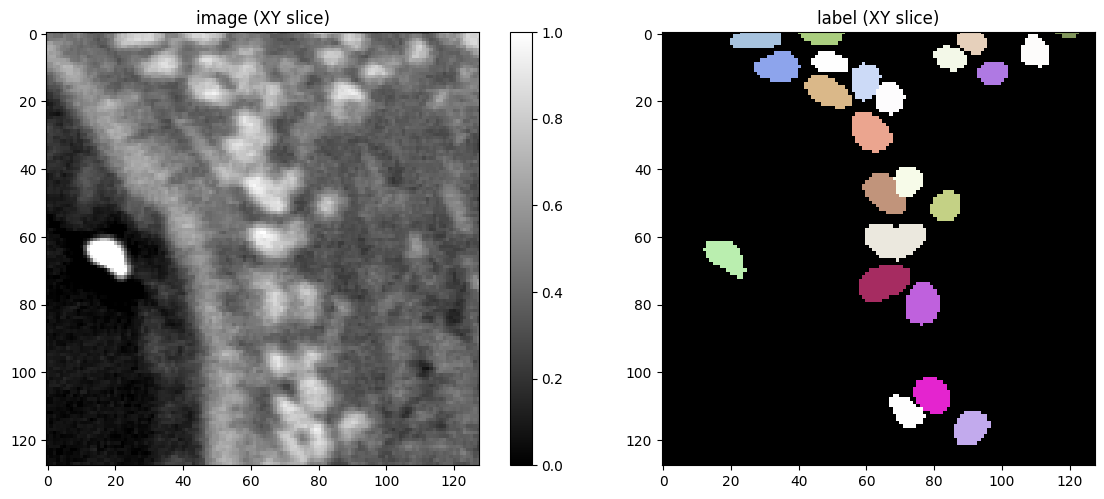

In [17]:
i = 1000
img, lbl = X[i], Y[i]
assert img.ndim in (3,4)
img = img if img.ndim==3 else img[...,:3]
plot_img_label(img,lbl)
None;

In [18]:
# print('ground truth shape is', Y.shape)
Ya = np.array(Y).astype(np.uint16)
extents = calculate_extents(Ya.squeeze().astype('uint16'))

anisotropy = tuple(np.max(extents) / extents)

# alternatively explicitly set extent and anisotropy

#extents = [80, 20, 20]
#anisotropy = (3,1,1)

print('extents', extents)
print('anisotropy', anisotropy)

extents [ 8. 11. 11.]
anisotropy (1.375, 1.0, 1.0)


In [19]:
n_channel = 1 if X[0].ndim == 3 else X[0].shape[-1]

# anisotropy = tuple([2, 1, 1])
n_rays = 96
use_gpu = True and gputools_available()
grid = tuple(1 if a > 1.5 else 2 for a in anisotropy)
rays = Rays_GoldenSpiral(n_rays, anisotropy=anisotropy)

persistent_dict.py (52): Unable to import recommended hash 'siphash24.siphash13', falling back to 'hashlib.sha256'. Run 'python3 -m pip install siphash24' to install the recommended hash.


If you want to compute separable approximations, please install it with
pip install scikit-tensor-py3


## Model setyp

In [20]:
conf = Config3D (
    rays             = rays,
    axes= 'ZYX',
    grid             = grid,
    anisotropy       = anisotropy,
    use_gpu          = use_gpu,
    n_channel_in     = n_channel,
    unet_n_depth = 3,
    # adjust for your data below (make patch size as large as possible)
    train_patch_size = (48,96,96),
    train_batch_size = 2,
    train_epochs= 400
)
print(conf)
vars(conf)

Config3D(n_dim=3, axes='ZYXC', n_channel_in=1, n_channel_out=97, train_checkpoint='weights_best.h5', train_checkpoint_last='weights_last.h5', train_checkpoint_epoch='weights_now.h5', n_rays=96, grid=(2, 2, 2), anisotropy=(1.375, 1.0, 1.0), backbone='unet', rays_json={'name': 'Rays_GoldenSpiral', 'kwargs': {'n': 96, 'anisotropy': (1.375, 1.0, 1.0)}}, n_classes=None, unet_n_depth=3, unet_kernel_size=(3, 3, 3), unet_n_filter_base=32, unet_n_conv_per_depth=2, unet_pool=(2, 2, 2), unet_activation='relu', unet_last_activation='relu', unet_batch_norm=False, unet_dropout=0.0, unet_prefix='', net_conv_after_unet=128, net_input_shape=(None, None, None, 1), net_mask_shape=(None, None, None, 1), train_patch_size=(48, 96, 96), train_background_reg=0.0001, train_foreground_only=0.9, train_sample_cache=True, train_dist_loss='mae', train_loss_weights=(1, 0.2), train_class_weights=(1, 1), train_epochs=400, train_steps_per_epoch=100, train_learning_rate=0.0003, train_batch_size=2, train_n_val_patches=No

{'n_dim': 3,
 'axes': 'ZYXC',
 'n_channel_in': 1,
 'n_channel_out': 97,
 'train_checkpoint': 'weights_best.h5',
 'train_checkpoint_last': 'weights_last.h5',
 'train_checkpoint_epoch': 'weights_now.h5',
 'n_rays': 96,
 'grid': (2, 2, 2),
 'anisotropy': (1.375, 1.0, 1.0),
 'backbone': 'unet',
 'rays_json': {'name': 'Rays_GoldenSpiral',
  'kwargs': {'n': 96, 'anisotropy': (1.375, 1.0, 1.0)}},
 'n_classes': None,
 'unet_n_depth': 3,
 'unet_kernel_size': (3, 3, 3),
 'unet_n_filter_base': 32,
 'unet_n_conv_per_depth': 2,
 'unet_pool': (2, 2, 2),
 'unet_activation': 'relu',
 'unet_last_activation': 'relu',
 'unet_batch_norm': False,
 'unet_dropout': 0.0,
 'unet_prefix': '',
 'net_conv_after_unet': 128,
 'net_input_shape': (None, None, None, 1),
 'net_mask_shape': (None, None, None, 1),
 'train_patch_size': (48, 96, 96),
 'train_background_reg': 0.0001,
 'train_foreground_only': 0.9,
 'train_sample_cache': True,
 'train_dist_loss': 'mae',
 'train_loss_weights': (1, 0.2),
 'train_class_weights'

In [21]:
# if use_gpu:
#     from csbdeep.utils.tf import limit_gpu_memory
#     # adjust as necessary: limit GPU memory to be used by TensorFlow to leave some to OpenCL-based computations
#     limit_gpu_memory(0.8)
#     # alternatively, try this:
#     # limit_gpu_memory(None, allow_growth=True)

In [22]:
model = StarDist3D(conf, name='Xray_long', basedir='models')

I0000 00:00:1739291354.596022  197384 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 30830 MB memory:  -> device: 0, name: Tesla V100-SXM2-32GB, pci bus id: 0000:61:00.0, compute capability: 7.0


Using default values: prob_thresh=0.5, nms_thresh=0.4.


In [23]:
median_size = calculate_extents(Y, np.median)
fov = np.array(model._axes_tile_overlap('ZYX'))
print(f"median object size:      {median_size}")
print(f"network field of view :  {fov}")
if any(median_size > fov):
    print("WARNING: median object size larger than field of view of the neural network.")

functional.py (237): The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(1, 128, 128, 128, 1))
I0000 00:00:1739291390.610935  198237 service.cc:148] XLA service 0x7ff1b0014d60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1739291390.610959  198237 service.cc:156]   StreamExecutor device (0): Tesla V100-SXM2-32GB, Compute Capability 7.0
2025-02-11 17:29:50.636507: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1739291390.704758  198237 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1739291391.041342  198237 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1739291391.210426  198237 gpu_timer.cc:82] Delay kernel timed out: m

median object size:      [ 8. 11. 11.]
network field of view :  [64 64 64]


In [24]:
model.train(X_trn, Y_trn, validation_data=(X_val,Y_val),  augmenter=augmenter)

Epoch 1/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 72s 544ms/step - dist_dist_iou_metric: 0.0369 - dist_loss: 4.9207 - dist_relevant_mae: 4.9205 - dist_relevant_mse: 70.9068 - loss: 1.3072 - prob_kld: 0.2915 - prob_loss: 0.3230 - val_dist_dist_iou_metric: 0.2780 - val_dist_loss: 2.7706 - val_dist_relevant_mae: 2.7690 - val_dist_relevant_mse: 15.1174 - val_loss: 0.6737 - val_prob_kld: 0.0877 - val_prob_loss: 0.1197 - learning_rate: 3.0000e-04
Epoch 2/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 27s 269ms/step - dist_dist_iou_metric: 0.2844 - dist_loss: 2.7021 - dist_relevant_mae: 2.7017 - dist_relevant_mse: 14.1892 - loss: 0.6556 - prob_kld: 0.0869 - prob_loss: 0.1152 - val_dist_dist_iou_metric: 0.3315 - val_dist_loss: 2.2289 - val_dist_relevant_mae: 2.2275 - val_dist_relevant_mse: 10.1356 - val_loss: 0.5485 - val_prob_kld: 0.0708 - val_prob_loss: 0.1028 - learning_rate: 3.0000e-04
Epoch 3/400
100/100 ━━━━━━━━━━━━━━━━━━━━ 27s 270ms/step - dist_dist_iou_metric: 0.2910 - dist_loss: 2.0878 - dist_relevant_mae: 

## Fine tune hyper parameters

In [25]:
model.optimize_thresholds(X_val[50:150], Y_val[50:150])

functional.py (237): The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(1, 64, 128, 128, 1))
E0000 00:00:1739302237.785064  198235 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1739302237.937320  198235 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1739302238.083591  198235 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1739302238.319874  198235 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1739302238.482733  198235 gpu_timer.cc:

Using optimized values: prob_thresh=0.449199, nms_thresh=0.3.
Saving to 'thresholds.json'.


{'prob': 0.4491986292330613, 'nms': 0.3}

In [63]:
i=71
Y_val_pred = model.predict_instances(X_val[i], n_tiles=model._guess_n_tiles(X_val[i]), show_tile_progress=True)[0]

100%|█████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  8.20it/s]


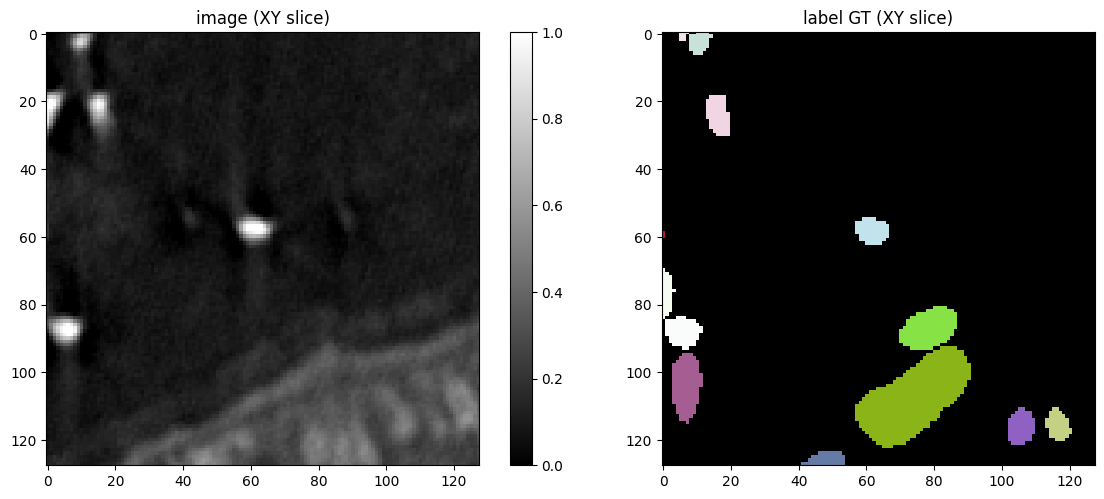

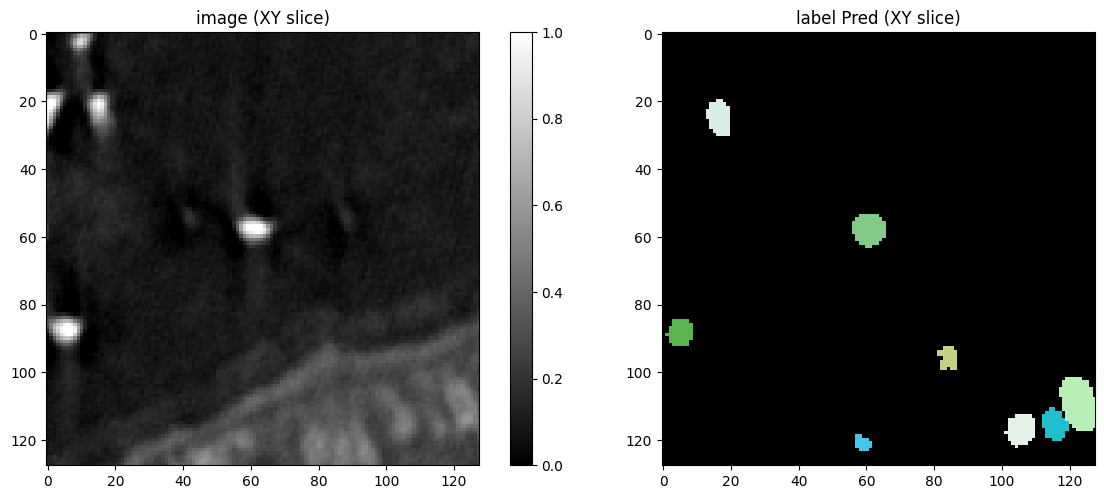

In [64]:
plot_img_label(X_val[i],Y_val[i], lbl_title="label GT (XY slice)")
plot_img_label(X_val[i],Y_val_pred, lbl_title="label Pred (XY slice)")

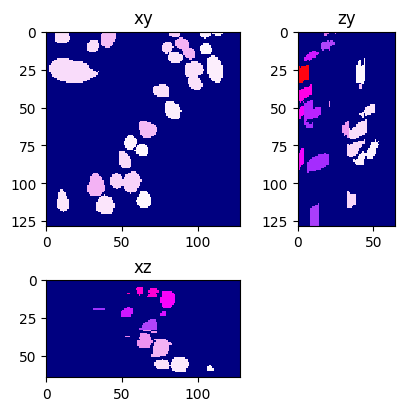

In [40]:
fig = show_xyz_slice_center(Y_val[i], colormap='gist_ncar', figsize=(4,4), show_cross_hairs=False)
fig.savefig('stardist_gt.png', bbox_inches='tight', dpi=200)

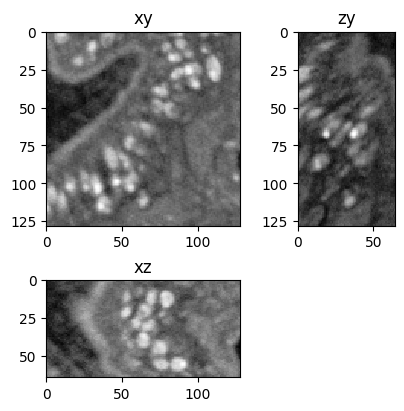

In [41]:
fig = show_xyz_slice_center(X_val[i], colormap='Greys_r', figsize=(4,4), )
fig.savefig('stardist_data.png', bbox_inches='tight', dpi=200)

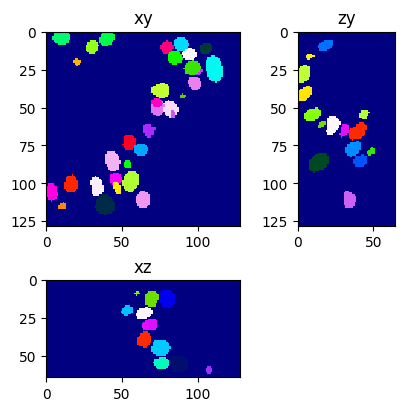

In [42]:
fig = show_xyz_slice_center(Y_val_pred, colormap='gist_ncar', figsize=(4,4), show_cross_hairs=False)
fig.savefig('stardist_pred.png', bbox_inches='tight', dpi=200)

In [65]:
i=89
Y_train_pred = model.predict_instances(X_trn[i], n_tiles=model._guess_n_tiles(X_trn[i]), show_tile_progress=True,)[0]

100%|█████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  8.54it/s]


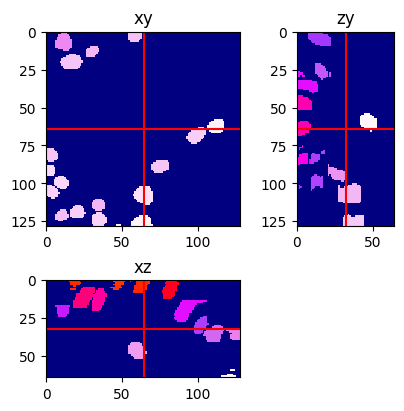

In [66]:
_ = show_xyz_slice_center(Y_trn[i], colormap='gist_ncar', figsize=(4,4), show_cross_hairs=True)

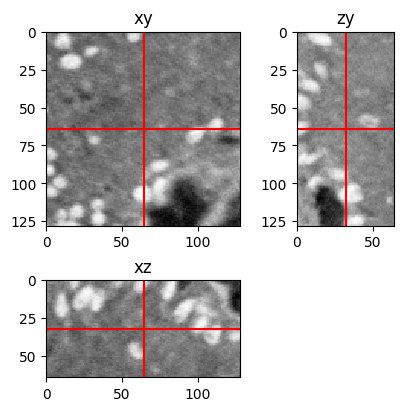

In [67]:
_ = show_xyz_slice_center(X_trn[i], colormap='Greys_r', figsize=(4,4), show_cross_hairs=True)

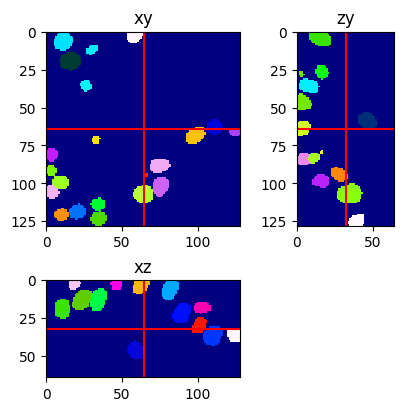

In [68]:
_ = show_xyz_slice_center(Y_train_pred, colormap='gist_ncar', figsize=(4,4), show_cross_hairs=True)

## Run the trained StarDist3D model on the data

In [4]:
model = StarDist3D(None,  name='Xray_long', basedir='models')

I0000 00:00:1739340686.934526  310613 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31134 MB memory:  -> device: 0, name: Tesla V100-SXM2-32GB, pci bus id: 0000:61:00.0, compute capability: 7.0


Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.449199, nms_thresh=0.3.


In [15]:
normed_img = normalize(data.image.values, axis=axis_norm)

In [16]:
model._guess_n_tiles(normed_img)

(9, 10, 14)

In [22]:
seg, _ = model.predict_instances(normed_img, n_tiles=(4, 6, 6), axes='ZYX', show_tile_progress=True)

  0%|                                                                           | 0/144 [00:00<?, ?it/s]E0000 00:00:1739341608.191753  310703 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-02-12 07:26:48.458772: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng13{} for conv (f32[1,32,224,304,384]{4,3,2,1,0}, u8[0]{0}) custom-call(f32[1,1,224,304,384]{4,3,2,1,0}, f32[32,1,3,3,3]{4,3,2,1,0}, f32[32]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
E0000 00:00:1739341608.630547  310703 gpu_timer.cc:82] Delay kernel timed ou

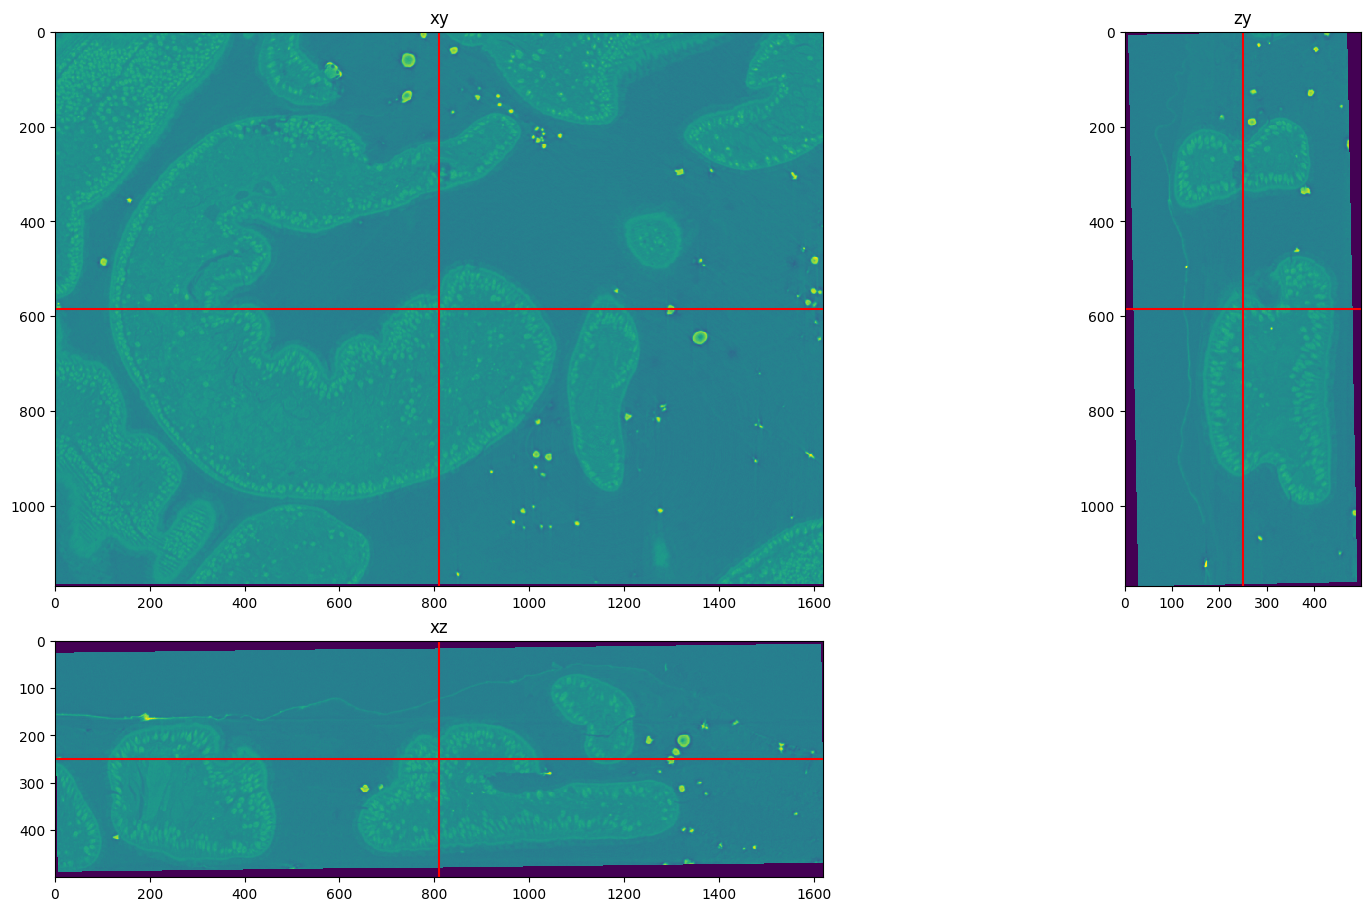

In [25]:
_ = show_xyz_slice_center(normed_img,  figsize=(16,9), show_cross_hairs=True)

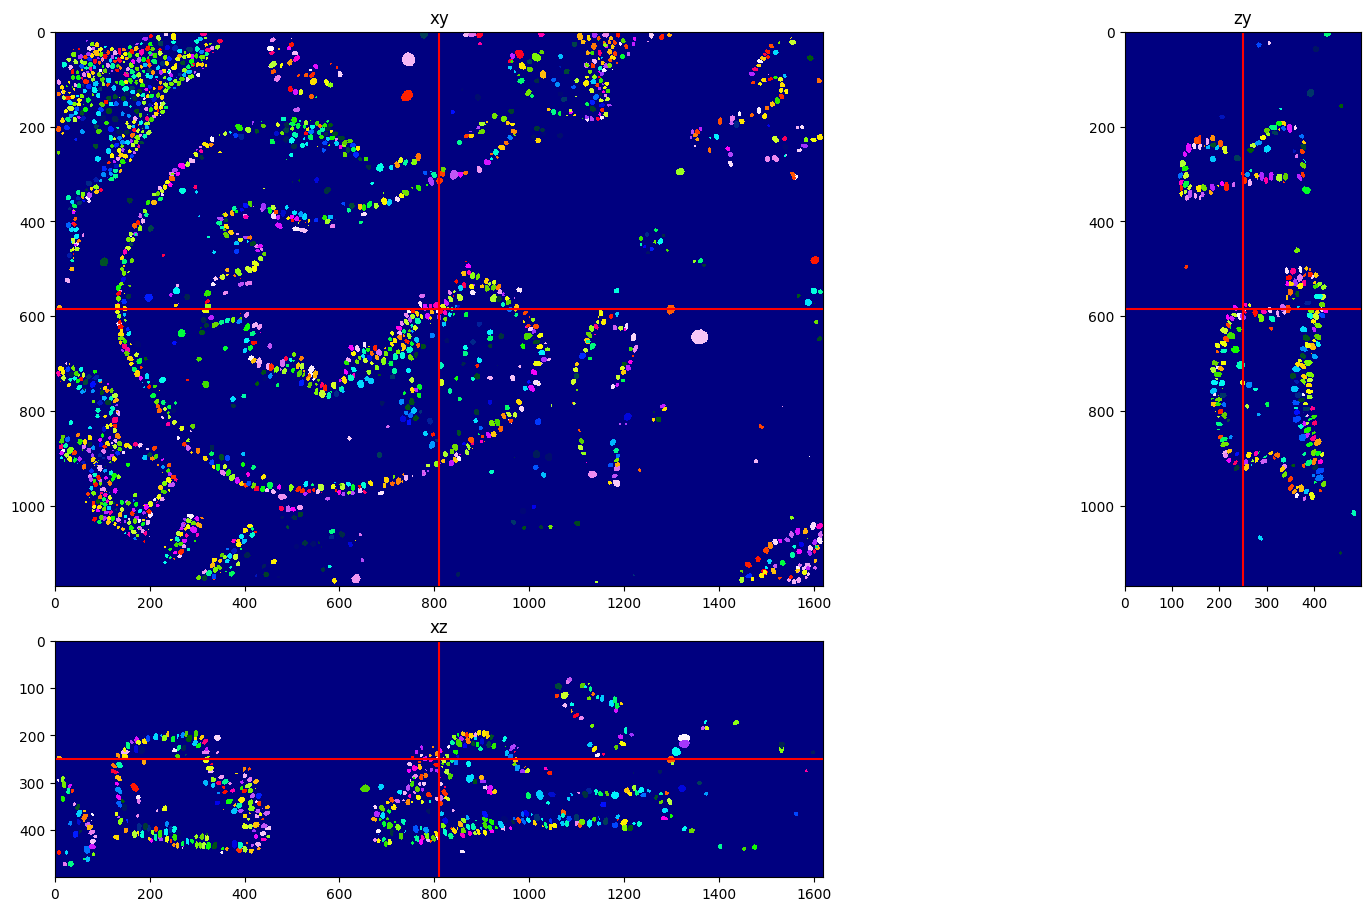

In [23]:
_ = show_xyz_slice_center(seg, colormap='gist_ncar', figsize=(16,9), show_cross_hairs=True)

## Save data

In [28]:
data['stardist'] = xr.DataArray(seg, dims=('z', 'y', 'x'))

In [30]:
data.to_zarr('/home/voehring/voehring/projects/2025-02-04_xray_pipeline/project/zarr/final.zarr')

In [32]:
# creating a file
with h5py.File('/home/voehring/voehring/projects/2025-02-04_xray_pipeline/project/hdf5/final.hdf5', 'w') as f: 
    dset = f.create_dataset("image", data = data.image.values)
    dset = f.create_dataset("segmentation", data = data.stardist.values)